# Кластеризация

## Описание датасета

1. Источник данных:

Обобщенные данные, полученные на основе статьи: Соотношение длины и веса девяти видов рыб из реки Тетулия, южная часть Бангладеш: https://www.researchgate.net/figure/Descriptive-statistics-and-estimated-length-weight-relationship-W-aL-b-W-in-g-and-L_tbl1_280916140

2. Метаданные:

- species: название вида
- length: длина (см)
- weight: вес (г)
- w_l_ratio: weight / length

За отсутствием необходимости в `w_l_ratio` для дальнешей задачи кластеризации уберем переменную из датасета

## Дескриптивный анализ

Размер датасета: (4080, 3)

Первые строки:
              species  length  weight
0  Anabas testudineus   10.66    3.45
1  Anabas testudineus    6.91    3.27
2  Anabas testudineus    8.38    3.46
3  Anabas testudineus    7.57    3.36
4  Anabas testudineus   10.83    3.38

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4080 entries, 0 to 4079
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   species  4080 non-null   object 
 1   length   4080 non-null   float64
 2   weight   4080 non-null   float64
dtypes: float64(2), object(1)
memory usage: 95.8+ KB
None

Описание признаков:
         count       mean       std   min      25%    50%     75%    max
length  4080.0  17.353544  7.114684  6.36  11.3275  17.35  22.585  33.86
weight  4080.0   3.739875  1.040365  2.05   3.0700   3.31   4.100   6.29

Количество пропусков:
species    0
length     0
weight     0
dtype: int64
  Параметр  Асимметрия   Эксцесс
0   l

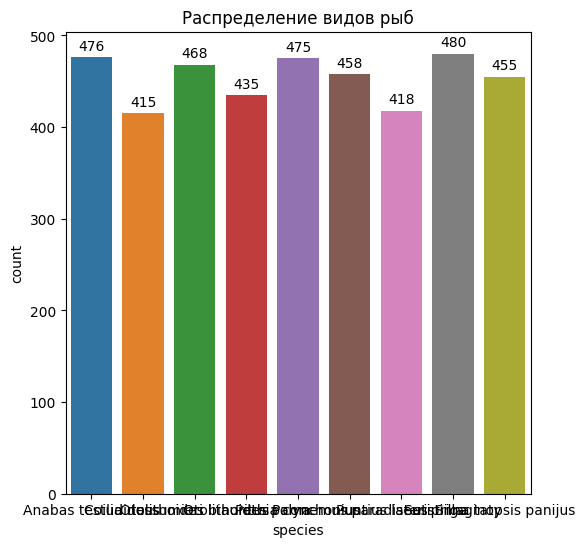

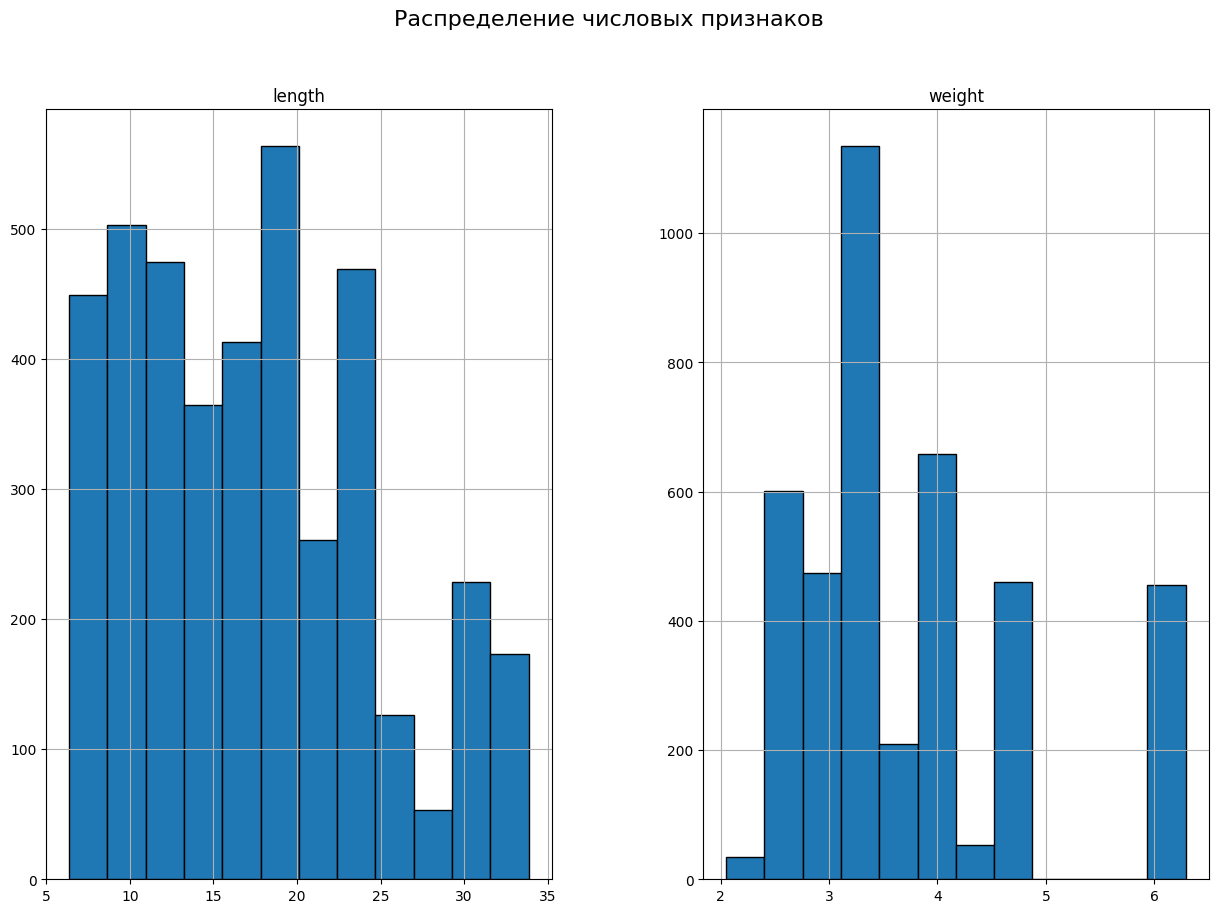

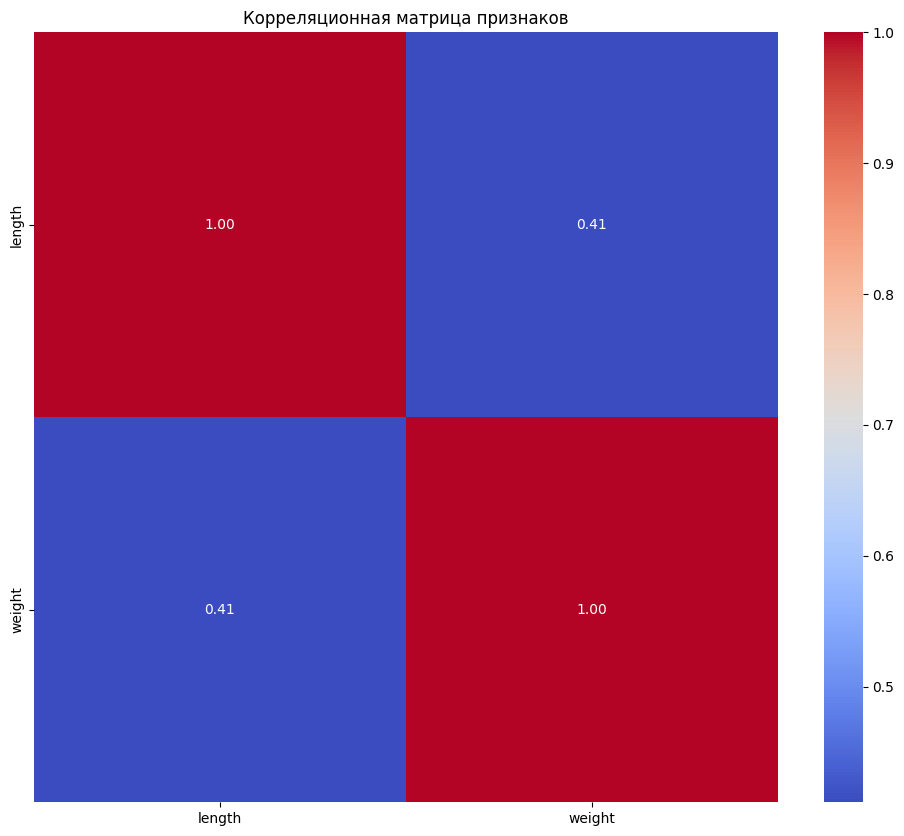

In [81]:
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, normaltest
import seaborn as sns

# Загрузка данных
df = pd.read_csv('fish_dataset.csv', sep=';')
df = df.fillna(df.mean(numeric_only=True))

# Описание и базовый анализ
num_cols = df.columns.drop('species')

print("Размер датасета:", df.shape)
print("\nПервые строки:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nОписание признаков:")
print(df.describe().T)
print("\nКоличество пропусков:")
print(df.isnull().sum())

# Асимметрия и эксцесс
param_data = {'Параметр': [], 'Асимметрия': [], 'Эксцесс': []}
for col in num_cols:
    param_data['Параметр'].append(col)
    param_data['Асимметрия'].append(skew(df[col].dropna()))
    param_data['Эксцесс'].append(kurtosis(df[col].dropna()))
summary_df = pd.DataFrame(param_data)
print(summary_df)

# Нормальность распределения (тест Д’Агостино-Пирсона)
print("\nПроверка нормальности распределения:")
for col in num_cols:
    stat, p = normaltest(df[col].dropna())
    print(f"{col}: статистика={stat:.4f}, p-значение={p:.4f}")
    if p > 0.05:
        print(" → распределение близко к нормальному\n")
    else:
        print(" → распределение отличается от нормального\n")

# График распределения значений stress_level
plt.figure(figsize=(6, 6))
ax = sns.countplot(x="species", hue='species', data=df)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.title("Распределение видов рыб")
plt.show()

# Гистограммы для числовых признаков
count_of_bins = int(1 + 3.322*math.log10(df.shape[0]))
df[num_cols].hist(bins=count_of_bins, figsize=(15, 10), edgecolor="black")
plt.suptitle("Распределение числовых признаков", fontsize=16)
plt.show()

# Корреляционный анализ
plt.figure(figsize=(12, 10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.show()

**Обоснование выбора методов кластеризации**

- KMeans и иерархическая кластеризация применимы, поскольку данные непрерывные, объем достаточен для статистики, отсутствуют пропуски, все признаки числовые.​

- DBSCAN также актуален, поскольку признаки имеют ненормальное распределение (о чём свидетельствуют результаты теста Д’Агостино-Пирсона, а также значения асимметрии и эксцесса), могут присутствовать выбросы (на гистограмме крайние значения), и требуется возможность выделения «шума»/аномалий, а не только глобальных кластеров.

**Проверка условий для кластеризации**

- Нормальность распределения отсутствует, что делает KMeans менее универсальным (идеален при близких к нормальным кластерах), но из-за объема можно применять — сенситивность алгоритма к ненормальности снижается при большом числе объектов.

- Классифицируемость признаков: по корреляционной матрице признаки неколлинеарны (r=0.41), то есть нет сильной линейной зависимости — оба признака значимы для кластеризации.

- Анализ структуры данных: гистограмма и асимметрия показывают наличие плотных областей и выбросов, а значит DBSCAN позволит выявлять не только компактные группы, но и «шум».

- Размер датасета (4080) позволяет использовать любые методы кластеризации — не критично по вычислительным ресурсам.

## Стандартизация переменных

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

# Проверим первые строки стандартизированного датасета и описательные статистики
scaled_head = df_scaled.head()
scaled_stats = df_scaled[num_cols].describe()
scaled_head, scaled_stats

(              species    length    weight
 0  Anabas testudineus -0.940922 -0.278662
 1  Anabas testudineus -1.468066 -0.451700
 2  Anabas testudineus -1.261425 -0.269049
 3  Anabas testudineus -1.375288 -0.365181
 4  Anabas testudineus -0.917025 -0.345955,
              length        weight
 count  4.080000e+03  4.080000e+03
 mean   1.393221e-16 -8.359326e-17
 std    1.000123e+00  1.000123e+00
 min   -1.545380e+00 -1.624509e+00
 25%   -8.470907e-01 -6.439637e-01
 50%   -4.982023e-04 -4.132471e-01
 75%    7.353941e-01  3.461951e-01
 max    2.320339e+00  2.451484e+00)

## Составные и категоризованные диаграммы рассеяния

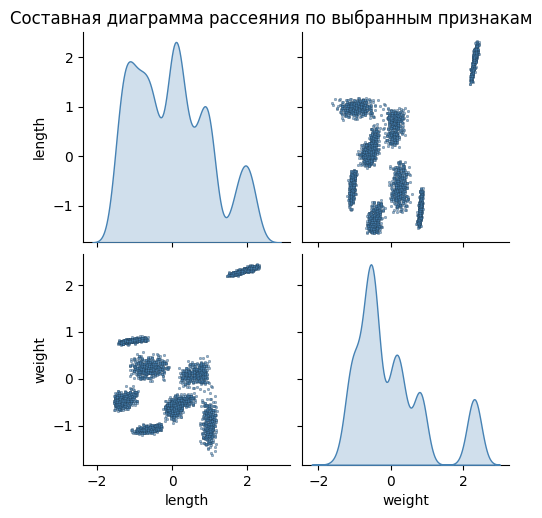

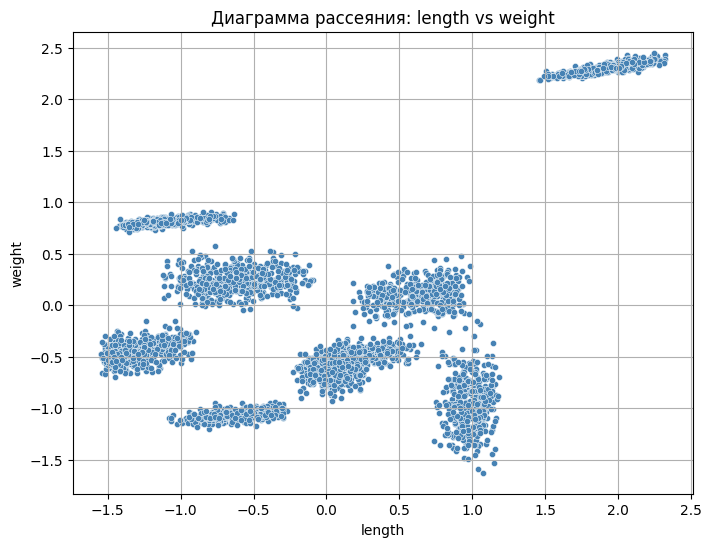

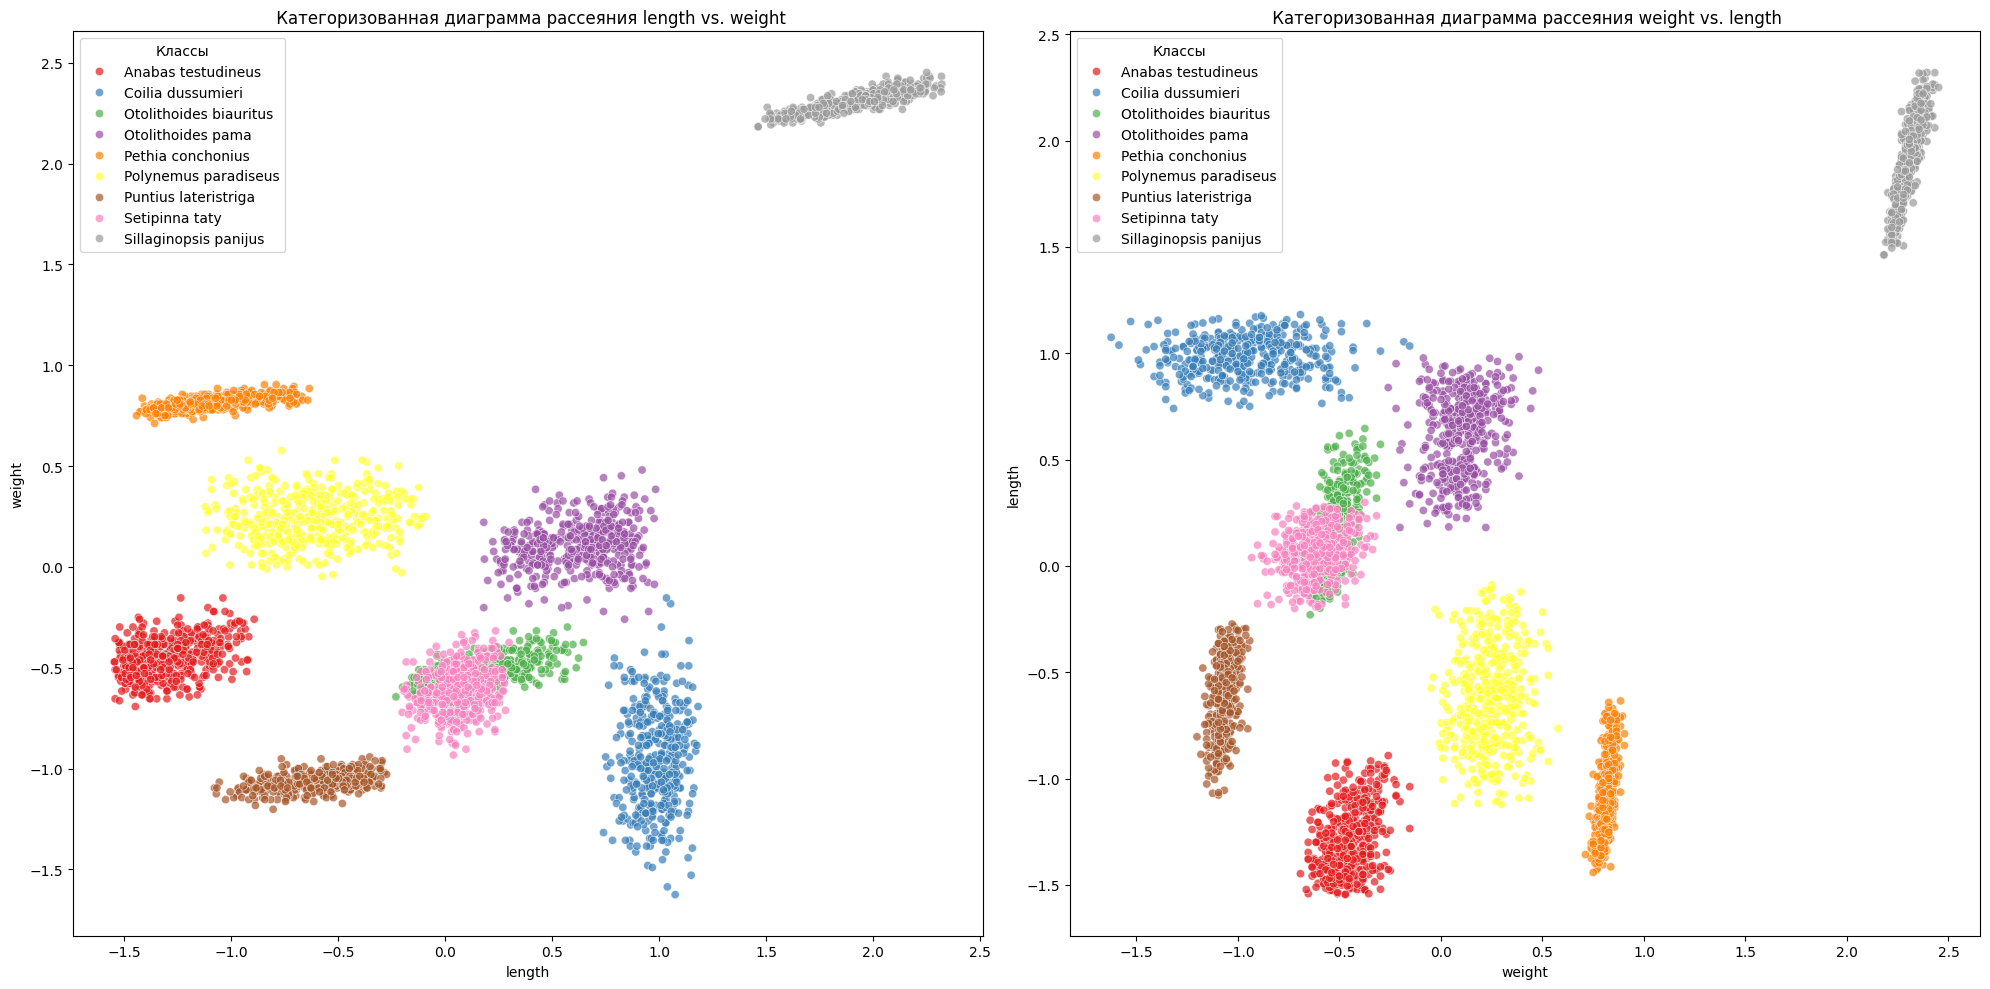

In [135]:
df_pairplot = df_scaled.drop(columns='species')

sns.pairplot(
    df_pairplot,
    diag_kind='kde',
    plot_kws={'color': 'steelblue', 'alpha': 0.6, 's': 4, 'edgecolor': 'k'},
    diag_kws={'color': 'steelblue'}
)
plt.suptitle("Составная диаграмма рассеяния по выбранным признакам", y=1.02)
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_scaled,
    x='length', y='weight',
    color='steelblue',
    s=20, alpha=1
)
plt.title("Диаграмма рассеяния: length vs weight")
plt.xlabel("length")
plt.ylabel("weight")
plt.grid(True)
plt.show()

pairs = [
    ('length', 'weight'),
    ('weight', 'length')
]
class_col = 'species'

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for i, (feature_x, feature_y) in enumerate(pairs):
    sns.scatterplot(
        data=df_scaled, x=feature_x, y=feature_y, hue=class_col, palette='Set1', alpha=0.7,
        ax=axes[i]
    )
    axes[i].set_title(f' Категоризованная диаграмма рассеяния {feature_x} vs. {feature_y}')
    axes[i].set_xlabel(feature_x)
    axes[i].set_ylabel(feature_y)
    axes[i].legend(title='Классы')

plt.tight_layout()
plt.show()



**Интерпретация графиков**

На составной диаграмме видны чётко отделённые облака точек в пространстве признаков length и weight.​ Каждая группа — компактна и чётко выражена, переходов между группами практически нет.

Количество ярко выраженных групп на графике соответствует ~8, причем одна из групп сильно отделена от основной массы.

Категоризованной диаграмме рассеяния отображено фактическое разделение по видам рыб, цветами помечены соответствующие классы.​ Видно, что каждая фактическая категория соответствует отдельному кластеру, и границы между кластерами практически не пересекаются за исключением розового и зеленого класса.

Кластеры по структуре — компактные, практические не пересекающиеся, эллипсоидные и вытянутые, т.е. соответствуют требованиям для алгоритмов типа KMeans и иерархической кластеризации.

Есть одна группа с заметно большими длинами и весами (серый цвет справа/вверху), выделяющаяся как отдельный крупный кластер.

## Метод K-средних

### Определение оптимального числа кластеров по методу локтя и методу силуэта

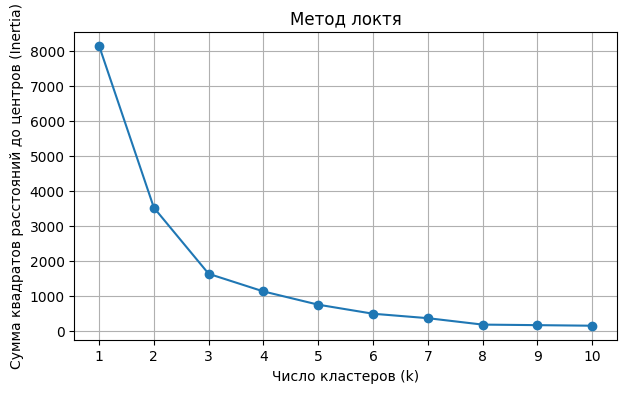

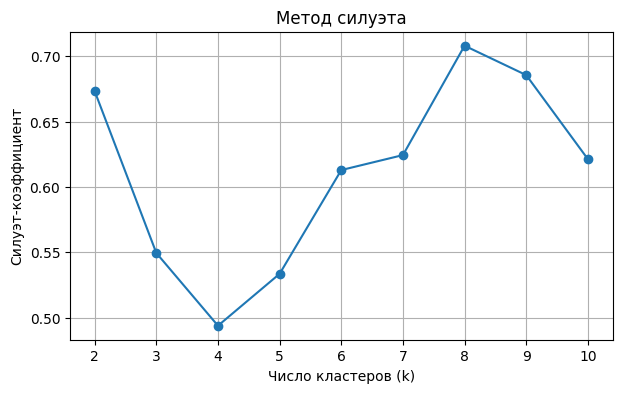

In [132]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = df_scaled[num_cols]

# Метод локтя
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++')
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K, inertia, marker='o')
plt.xlabel("Число кластеров (k)")
plt.ylabel("Сумма квадратов расстояний до центров (Inertia)")
plt.xticks(range(1, len(inertia)+1))
plt.title("Метод локтя")
plt.grid(True)
plt.show()

# Метод силуэта
silhouette_scores = []
K_silhouette = range(2, 11)
for k in K_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++')
    labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

plt.figure(figsize=(7, 4))
plt.plot(K_silhouette, silhouette_scores, marker='o')
plt.xlabel("Число кластеров (k)")
plt.ylabel("Силуэт-коэффициент")
plt.title("Метод силуэта")
plt.grid(True)
plt.show()

- Метод локтя указывает на оптимальное значение k=3, когда резкое снижение компактности становится менее заметным.

- Метод силуэта выделяет максимум качества для k=8, соответствующего количеству биологических видов (или максимуму разделимости в пространстве признаков).

**Итоговое решение:** число кластеров следует выбирать с учётом поставленной задачи — для выявления крупных групп k=3; для предельно детального деления k=8.

### Исполнение алгоритма k-средних с заданным числом кластеров

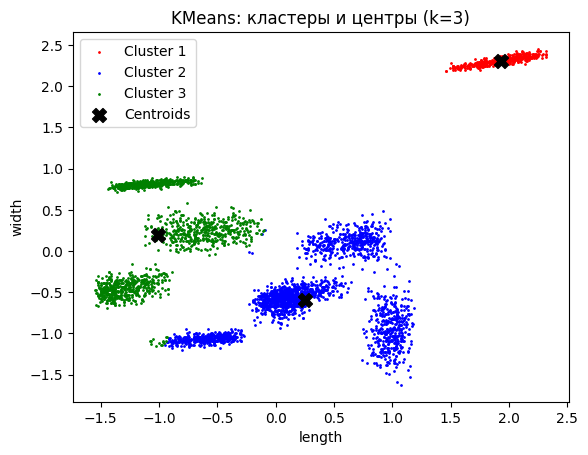

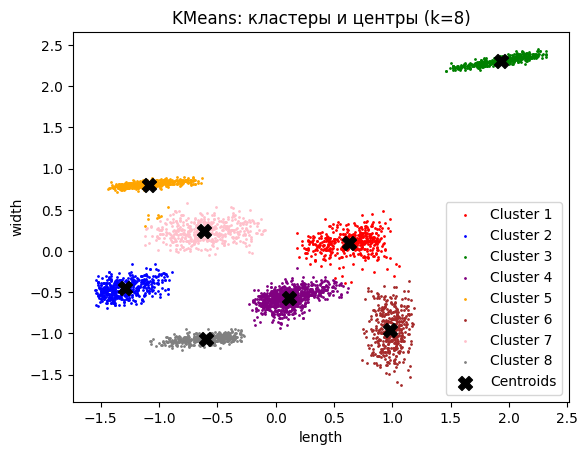

In [134]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = df_scaled[num_cols].values 

k = 3
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'cyan', 'olive']
for i in range(k):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1],
                s=1, c=colors[i % len(colors)],
                label=f'Cluster {i+1}')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=100, c='black', label='Centroids', marker='X')
plt.title(f'KMeans: кластеры и центры (k={k})')
plt.xlabel('length')
plt.ylabel('width')
plt.legend()
plt.show()

k = 8
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'cyan', 'olive']
for i in range(k):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1],
                s=1, c=colors[i % len(colors)],
                label=f'Cluster {i+1}')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=100, c='black', label='Centroids', marker='X')
plt.title(f'KMeans: кластеры и центры (k={k})')
plt.xlabel('length')
plt.ylabel('width')
plt.legend()
plt.show()


- **При k=3** кластеризация хорошо отражает макроуровневую структуру данных: самая крупная и отличающаяся группа отделена чётко, остальные более похожие виды собраны в обобщённые группы.

- Точное совпадение с реальными классами отсутствует: вместо восьми биологических видов получаем три агрегированных кластера.

- Такой подход подходит для задач предварительного анализа, грубой классификации и определения основных групп.

- **Кластеризация KMeans при k=8** обеспечивает максимально полное  и точное соответствие (за исключением перекрывающего класса) с реальными классами, что делает её оптимальным решением для биологических данных с чётко выраженными видами. Каждый кластер возникает строго в позиции одного биологического класса, а границы между видами чётко соблюдаются

## DBSCAN

**Принцип работы DBSCAN**

- **DBSCAN** — алгоритм кластеризации по плотности, не требует задания числа кластеров заранее.

- Кластеры формируются как области с высокой плотностью точек, а отдельные точки вне плотных областей классифицируются как шум.

- Параметры eps и min_samples определяют:

    - максимальную дистанцию для соседства `eps`,

    - минимальное количество точек для образования кластера `min_samples`.


Число кластеров без шума: 8


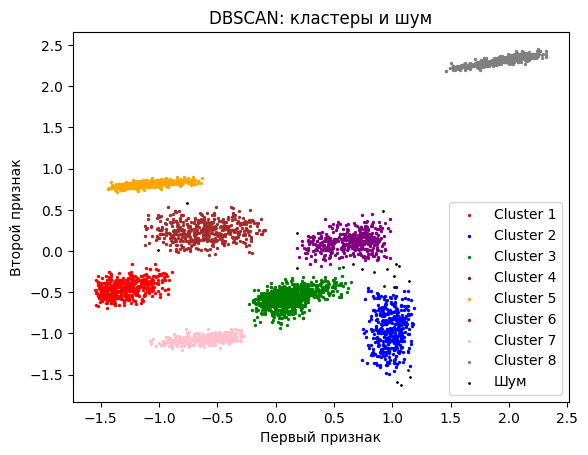

In [139]:
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X = df_scaled[num_cols].values

# Задайте параметры eps и min_samples под ваши данные
dbscan = DBSCAN(eps=0.1, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

# Количество кластеров (кроме шума)
n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
print(f'Число кластеров без шума: {n_clusters}')

colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'cyan', 'olive']

for cluster_label in set(y_dbscan):
    if cluster_label == -1:
        # Шум отображаем черным цветом
        color = 'black'
        label = 'Шум'
        size = 1
    else:
        color = colors[cluster_label % len(colors)]
        label = f'Cluster {cluster_label + 1}'
        size = 2
    plt.scatter(X[y_dbscan == cluster_label, 0], X[y_dbscan == cluster_label, 1],
                s=size, c=color, label=label)

plt.title('DBSCAN: кластеры и шум')
plt.xlabel('Первый признак')
plt.ylabel('Второй признак')
plt.legend()
plt.show()


- DBSCAN-кластеризация (eps=0.1, min_samples=5) практически идеально согласуется с фактическим разделением классов по видам рыб.

- На графике DBSCAN видны восемь компактных и хорошо разделённых кластеров, а также небольшое количество точек, обозначенных как "шум" (чёрные точки).​

- График DBSCAN показывают восемь чётко выраженных групп, почти полностью (за исключением перекрывающего класса) совпадающих по расположению и структуре с кластерами на категоризованной диаграмме рассеяния.​

- Шумовые точки расположены на границах групп либо в редких, слабо населённых областях пространства — это характерно для правильной работы DBSCAN: он не включает выбросы и аномалии в кластеры.

## Оценка качества построенных моделей

In [137]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, jaccard_score
from scipy.spatial.distance import cdist

X = df_scaled[num_cols]
y_true = df_scaled['species']

# --- KMeans ----
k = 8  # или другое оптимальное значение
kmeans = KMeans(n_clusters=k, random_state=42)
labels_kmeans = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

# Внутрикластерные расстояния (среднее и максимум)
intra_dist = [np.mean(np.linalg.norm(X[labels_kmeans==i] - centers[i], axis=1)) for i in range(k)]
intra_dist_mean = np.mean(intra_dist)
intra_dist_max = np.max(intra_dist)

# Расстояния между центроидами (минимум, максимум, среднее)
inter_dist = cdist(centers, centers)
mask = ~np.eye(k, dtype=bool)
inter_distances = inter_dist[mask]
inter_dist_min = np.min(inter_distances)
inter_dist_max = np.max(inter_distances)
inter_dist_mean = np.mean(inter_distances)

print(f"KMeans ({k} кластеров)")
print(f"- Внутрикластерное расстояние (среднее/макс.): {intra_dist_mean:.4f} / {intra_dist_max:.4f}")
print(f"- Межкластерное расстояние (мин/сред/макс): {inter_dist_min:.4f} / {inter_dist_mean:.4f} / {inter_dist_max:.4f}")
print(f"- Компактность (inertia): {kmeans.inertia_:.4f}")
print(f"- Центры: \n{centers}\n")

# Внутренние индексы
print(f"- Silhouette: {silhouette_score(X, labels_kmeans):.4f}")
print(f"- Calinski-Harabasz: {calinski_harabasz_score(X, labels_kmeans):.2f}")
print(f"- Davies-Bouldin: {davies_bouldin_score(X, labels_kmeans):.4f}")

# Внешние метрики (если есть y_true)
if 'y_true' in locals():
    print(f"- Adjusted Rand Index: {adjusted_rand_score(y_true, labels_kmeans):.4f}")
    print(f"- NMI: {normalized_mutual_info_score(y_true, labels_kmeans):.4f}")
    if len(np.unique(y_true)) == k:
        print(f"- Jaccard (macro): {jaccard_score(y_true, labels_kmeans, average='macro'):.4f}")

print("\n"+"-"*40+"\n")

# --- DBSCAN ----
# Параметры eps и min_samples подобраны заранее!
dbscan = DBSCAN(eps=0.1, min_samples=5)
labels_dbscan = dbscan.fit_predict(X)
core_labels = labels_dbscan[labels_dbscan != -1]
n_clusters_dbscan = len(set(core_labels))

print(f"DBSCAN (eps=0.1, min_samples=5)")
print(f"- Обнаружено кластеров (без шума): {n_clusters_dbscan}")

# Внутренние индексы только если больше 1 кластера
if n_clusters_dbscan > 1:
    print(f"- Silhouette: {silhouette_score(X[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1]):.4f}")
    print(f"- Calinski-Harabasz: {calinski_harabasz_score(X[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1]):.2f}")
    print(f"- Davies-Bouldin: {davies_bouldin_score(X[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1]):.4f}")
else:
    print("- Слишком мало кластеров для внутренних индексов")

# Внешние метрики (если есть y_true)
if 'y_true' in locals() and n_clusters_dbscan > 1:
    print(f"- Adjusted Rand Index: {adjusted_rand_score(y_true[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1]):.4f}")
    print(f"- NMI: {normalized_mutual_info_score(y_true[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1]):.4f}")
    if len(np.unique(y_true[labels_dbscan != -1])) == n_clusters_dbscan:
        print(f"- Jaccard (macro): {jaccard_score(y_true[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1], average='macro'):.4f}")

# Центры DBSCAN, если нужно
dbscan_centers = [np.mean(X[labels_dbscan==i], axis=0) for i in range(n_clusters_dbscan)]

print(f"- Центры кластеров (DBSCAN):\n{dbscan_centers}")



KMeans (8 кластеров)
- Внутрикластерное расстояние (среднее/макс.): 0.1805 / 0.2266
- Межкластерное расстояние (мин/сред/макс): 0.7420 / 1.9692 / 4.2395
- Компактность (inertia): 174.8031
- Центры: 
[[ 0.62830845  0.09879676]
 [-1.28966084 -0.45050832]
 [ 1.9277116   2.31030759]
 [ 0.11326651 -0.56834129]
 [-1.08826917  0.80629481]
 [ 0.98258518 -0.95919242]
 [-0.61216584  0.2371174 ]
 [-0.60187224 -1.0642534 ]]

- Silhouette: 0.7080
- Calinski-Harabasz: 26573.47
- Davies-Bouldin: 0.3983
- Adjusted Rand Index: 0.8693
- NMI: 0.9518

----------------------------------------

DBSCAN (eps=0.1, min_samples=5)
- Обнаружено кластеров (без шума): 8
- Silhouette: 0.7105
- Calinski-Harabasz: 26978.41
- Davies-Bouldin: 0.3958
- Adjusted Rand Index: 0.8748
- NMI: 0.9609
- Центры кластеров (DBSCAN):
[length   -1.289661
weight   -0.450508
dtype: float64, length    0.981094
weight   -0.957496
dtype: float64, length    0.116093
weight   -0.567210
dtype: float64, length    0.625154
weight    0.109453
d

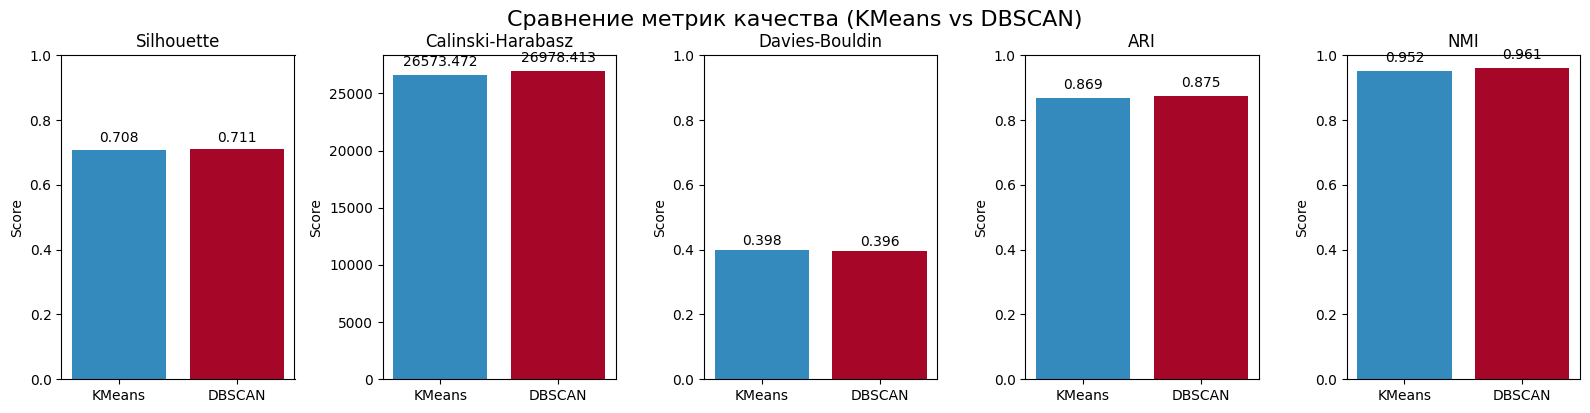

In [148]:
metrics = {
    "Silhouette": [
        silhouette_score(X, labels_kmeans),
        silhouette_score(X[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1])
    ],
    "Calinski-Harabasz": [
        calinski_harabasz_score(X, labels_kmeans),
        calinski_harabasz_score(X[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1])
    ],
    "Davies-Bouldin": [
        davies_bouldin_score(X, labels_kmeans),
        davies_bouldin_score(X[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1])
    ],
    "ARI": [
        adjusted_rand_score(y_true, labels_kmeans),
        adjusted_rand_score(y_true[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1])
    ],
    "NMI": [
        normalized_mutual_info_score(y_true, labels_kmeans),
        normalized_mutual_info_score(y_true[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1])
    ]
}

methods = ['KMeans', 'DBSCAN']
colors = ['#348ABD', '#A60628']

fig, axes = plt.subplots(1, len(metrics), figsize=(16, 4))
for idx, (metric, scores) in enumerate(metrics.items()):
    bars = axes[idx].bar(methods, scores, color=colors)
    axes[idx].set_title(metric)
    axes[idx].set_ylim(0, 1 if metric not in ['Calinski-Harabasz'] else None)
    axes[idx].set_ylabel('Score')
    # Добавляем подписи
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02 * height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.tight_layout()
plt.suptitle('Сравнение метрик качества (KMeans vs DBSCAN)', fontsize=16, y=1.02)
plt.show()

| Метрика                                    | KMeans (k=8)      | DBSCAN           | Интерпретация                                             |
|---------------------------------------------|-------------------|------------------|-----------------------------------------------------------|
| Внутрикластерное расстояние (среднее/макс.) | 0.1805 / 0.2266   | ---              | Чем меньше, тем компактнее кластеры                       |
| Межкластерное расстояние (мин/ср/макс)      | 0.7420 / 1.9692 / 4.2395 | ---        | Чем больше, тем сильнее кластеры разделены между собой    |
| Компактность (inertia)                      | 174.8031          | ---              | Сумма квадратов расстояний до центров |
| Количество кластеров                        | 8                 | 8                | Число кластеров без учёта шума                            |
| Silhouette                                  | 0.7080            | 0.7105           | Ближе к 1 — отличное разделение кластеров                 |
| Calinski-Harabasz                           | 26573.47          | 26978.41         | Больше — лучше межкластерная дисперсия                    |
| Davies-Bouldin                              | 0.3983            | 0.3958           | Меньше — кластеры более компактны и хорошо разделены      |
| Adjusted Rand Index                         | 0.8693            | 0.8748           | Ближе к 1 — лучшее совпадение с истинными классами        |
| NMI                                         | 0.9518            | 0.9609           | Ближе к 1 — высокая информативность кластеризации         |

**Центры кластеров (KMeans, DBSCAN)**

- Почти совпадают (KMeans, DBSCAN идентифицируют группы аналогично), что подтверждает высокое качество кластеризации.
- Дают представление о "типичном" элементе каждого найденного кластера.


**Вывод:** 

Метрики KMeans и DBSCAN близки друг к другу, оба метода дают очень хорошее совпадение с истинной разметкой (высокие ARI, NMI, silhouette score). Кластеры компактны и чётко разделены.  
DBSCAN идеально подходит для данных с произвольной формой кластеров и выбросами, а KMeans — для "сферичных", равномерно расположенных групп с известным числом (k). Высокие значения внешних метрик говорят о совпадении с фактическими классами, внутренние — о разделимости групп и компактности внутри них.


## Сравнительный анализ решений

![k is 3.png](<attachment:k is 3.png>)
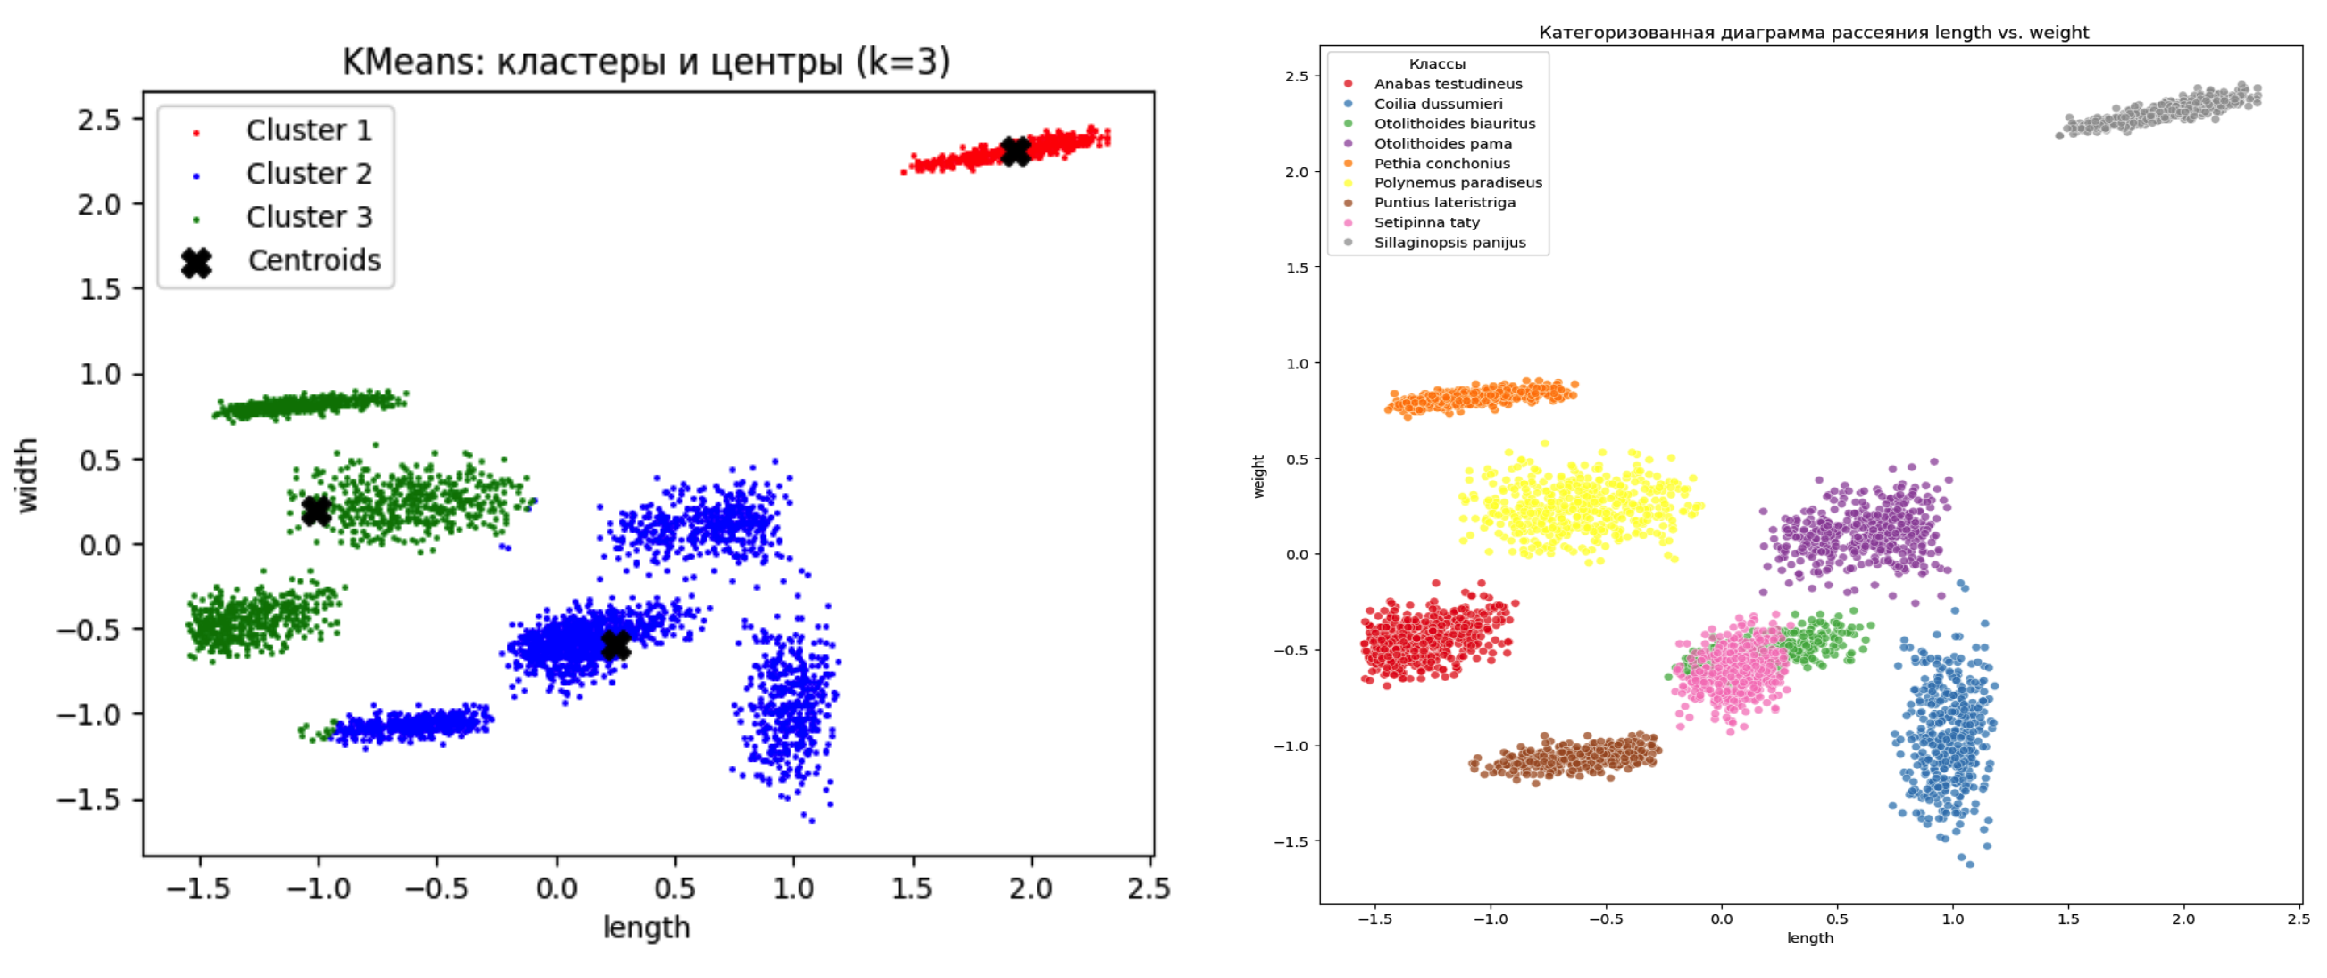

![k is 8.png](<attachment:k is 8.png>)
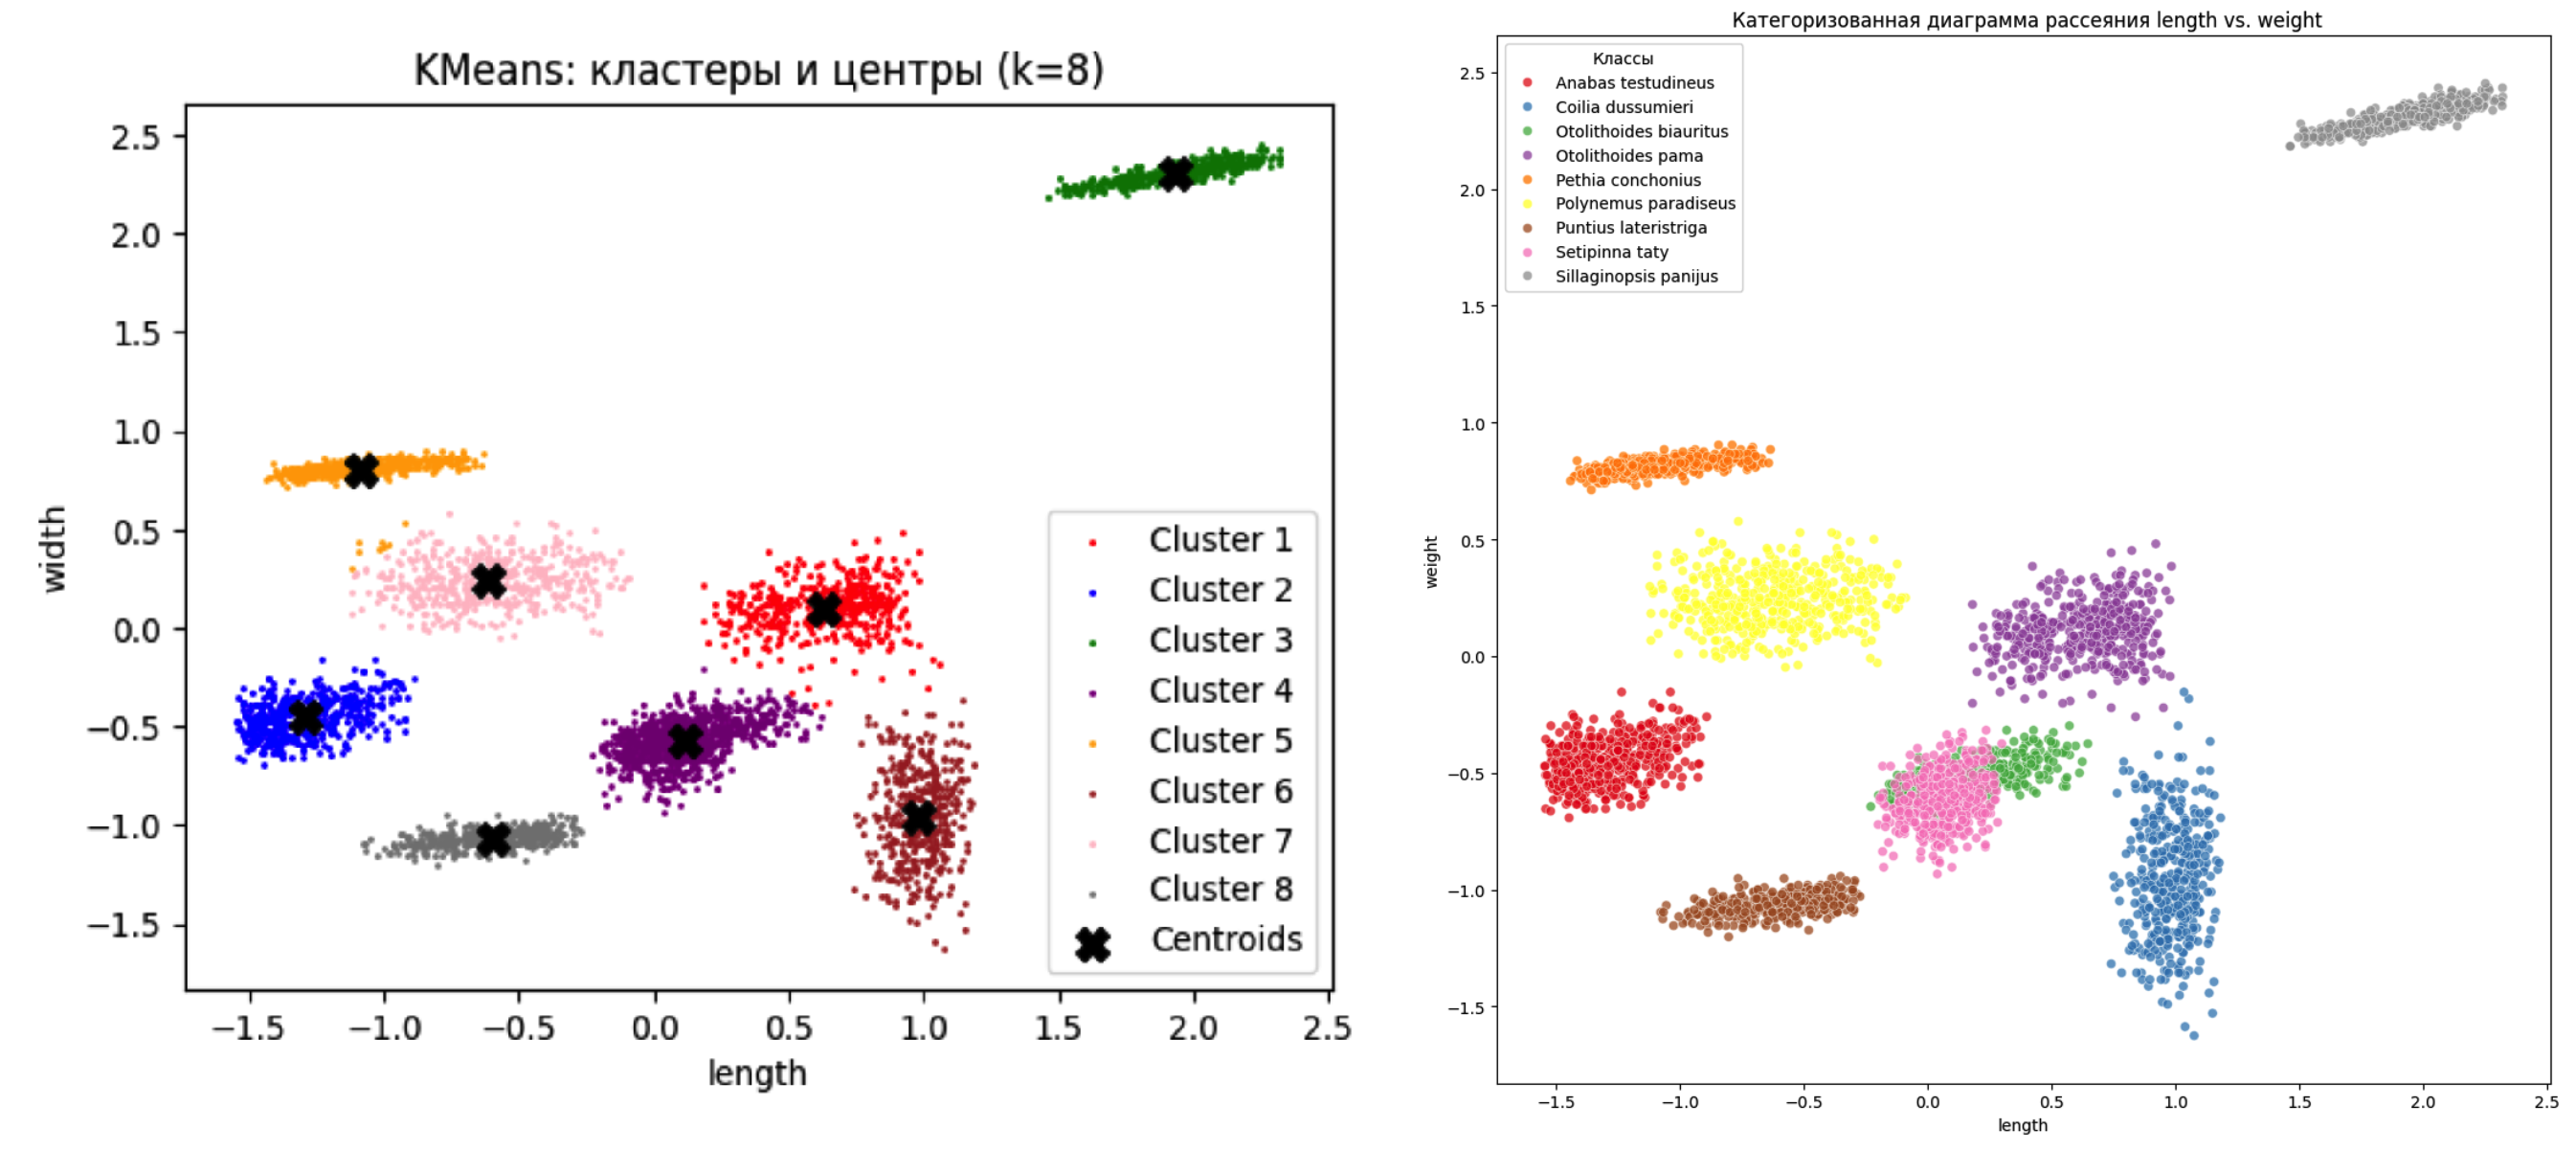

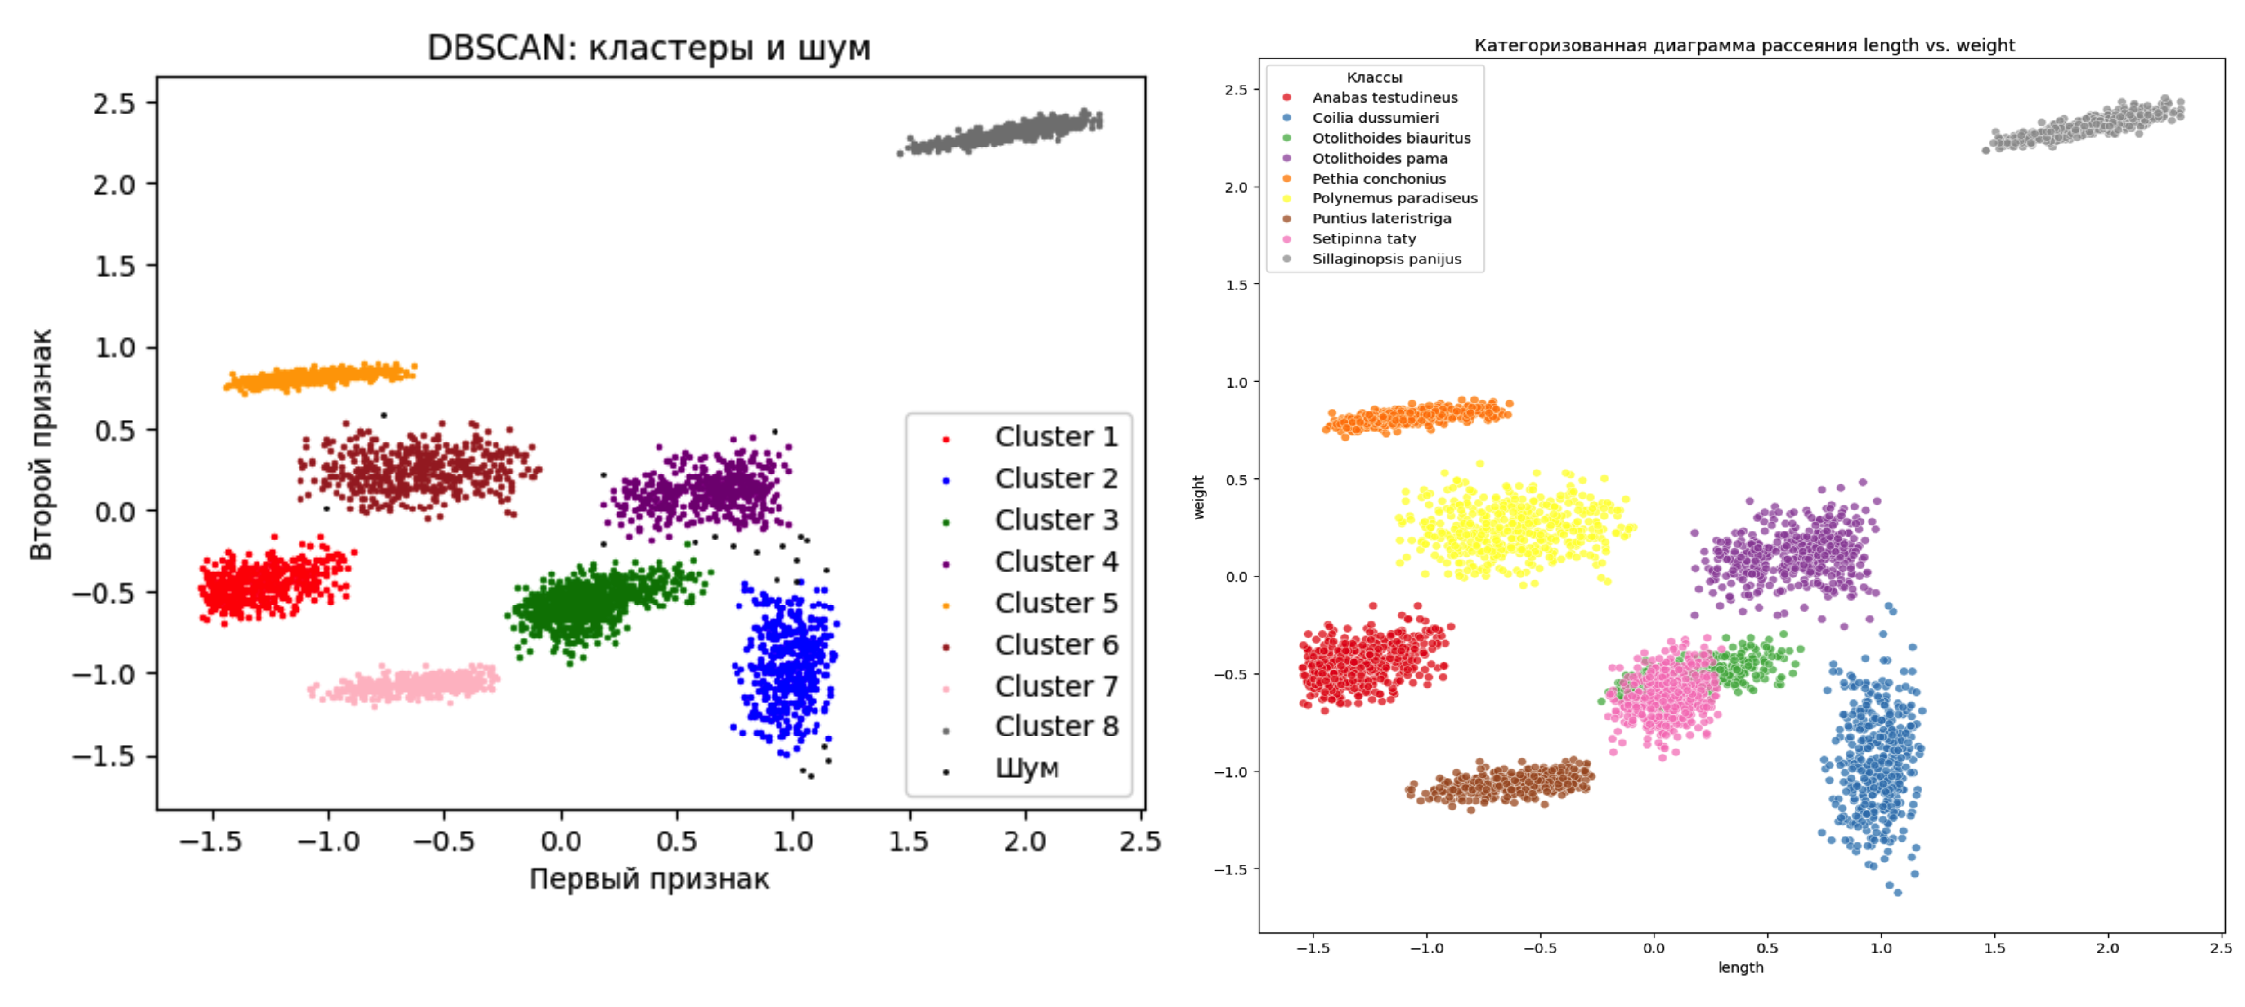

Метод k-средних для трех кластеров хорошо отражает **макроуровневую структуру данных:** самая крупная и отличающаяся группа отделена чётко, остальные более похожие виды собраны в обобщённые группы.

Метод же KMeans с 8 кластерами и DBSCAN при параметрах `eps=0.1`, `min_samples=5` дают практически идентичные разбиения данных по качественным метрикам и по геометрии кластеров. Однако различия проявляются в деталях работы, устойчивости к шуму и способах идентификации кластеров.

Для обоих алгоритмов значения известнейших метрик близки:

- Silhouette: KMeans — 0.7080, DBSCAN — 0.7105. Оба значения очень высокие (практически идеальная разделимость кластеров).

- Calinski-Harabasz: KMeans — 26573.47, DBSCAN — 26978.41. Оба варианта показывают высокую внутрикластерную плотность и межкластерное разделение.

- Davies-Bouldin: KMeans — 0.3983, DBSCAN — 0.3958. Низкие значения говорят о малом перекрытии между большинством кластеров.

- ARI (Adjusted Rand Index): KMeans — 0.8693, DBSCAN — 0.8748. Классификация схожа с эталонной разметкой.

- NMI: KMeans — 0.9518, DBSCAN — 0.9609. Почти идеальная согласованность с истинными метками.

**KMeans** хорошо работает на компактных, шарообразных кластерах с примерно одинаковым числом точек, но не умеет выявлять шум.

**DBSCAN** умеет отличать мажорные группы от шумовых точек и гибко адаптируется к форме и плотности кластеров.

Оба алгоритма отлично срабатывают на этих данных, но DBSCAN будет устойчивее при наличии выбросов или неравных плотностей.

## Исследование влияния параметров DBSCAN на качество решения

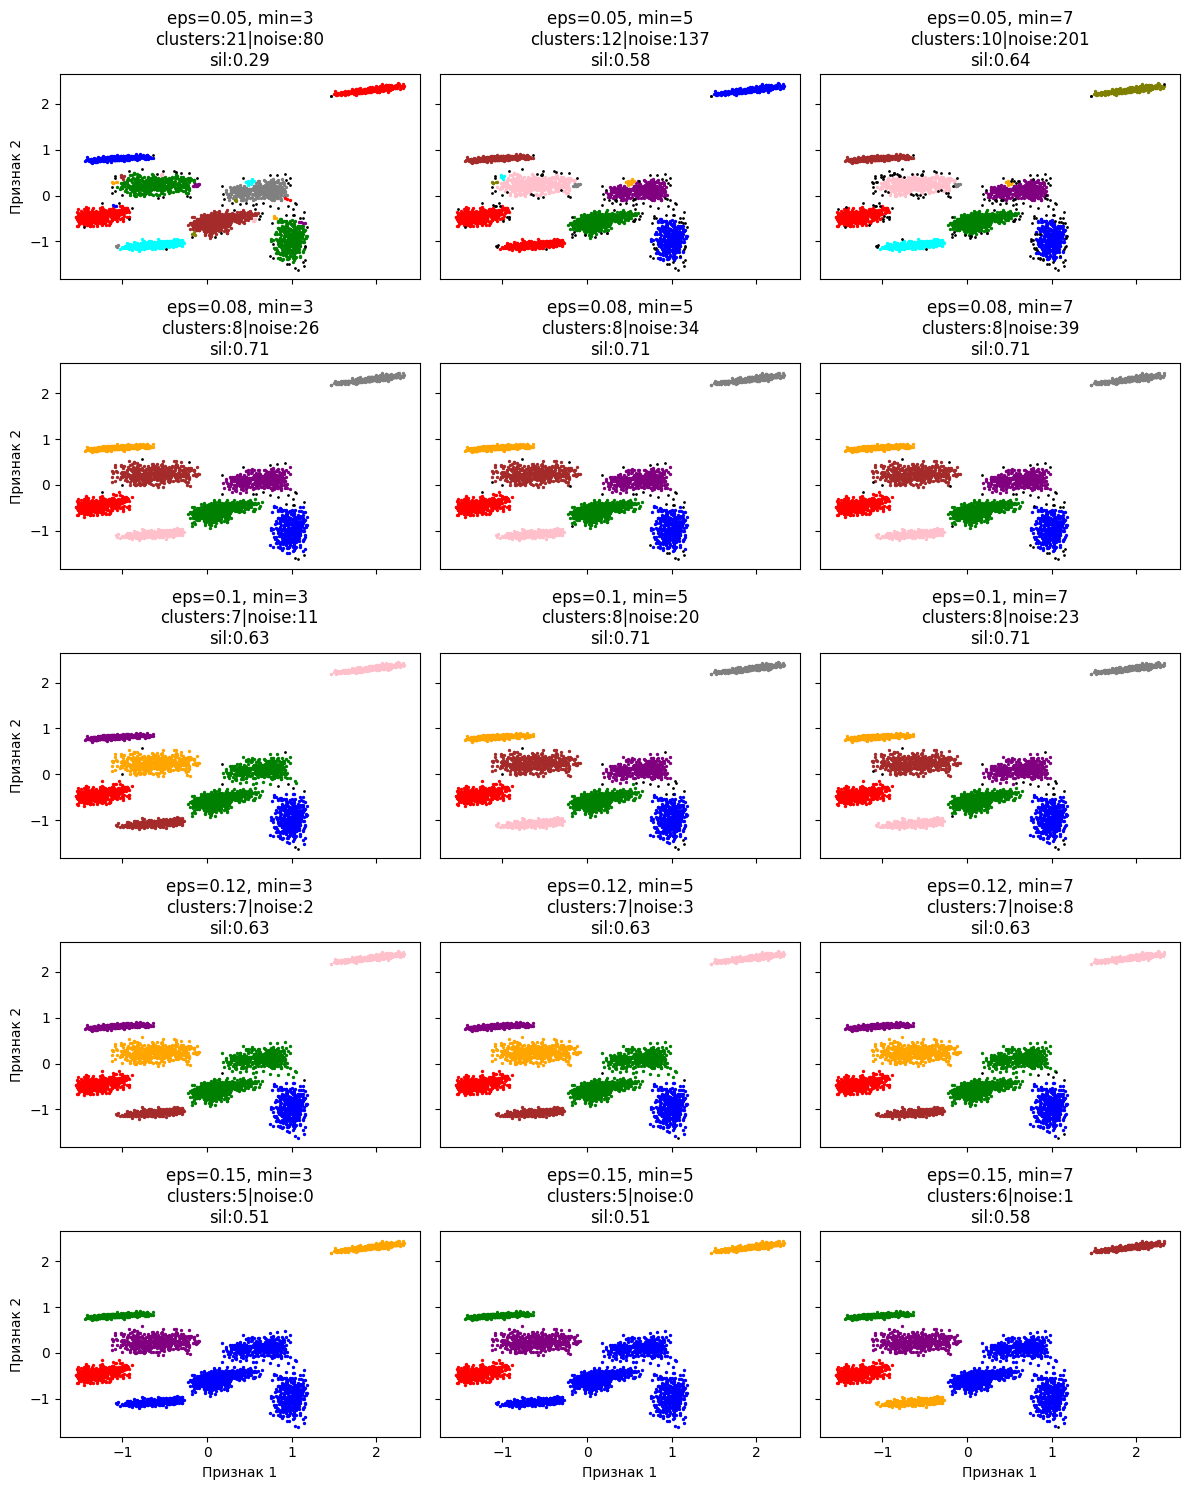

     eps  min_samples  n_clusters  n_noise  silhouette       ARI       NMI
0   0.05            3          21       80    0.290769  0.860387  0.944104
1   0.05            5          12      137    0.580082  0.866213  0.953296
2   0.05            7          10      201    0.640388  0.867413  0.956736
3   0.08            3           8       26    0.711248  0.875168  0.961676
4   0.08            5           8       34    0.712404  0.874980  0.961636
5   0.08            7           8       39    0.712955  0.874725  0.961584
6   0.10            3           7       11    0.632791  0.701397  0.905826
7   0.10            5           8       20    0.710531  0.874760  0.960865
8   0.10            7           8       23    0.711423  0.875563  0.961747
9   0.12            3           7        2    0.631241  0.700270  0.905043
10  0.12            5           7        3    0.631233  0.700167  0.905017
11  0.12            7           7        8    0.632269  0.701785  0.906516
12  0.15            3    

In [145]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import pandas as pd

X = df_scaled[num_cols].values
y_true = df_scaled['species'].values

eps_values = [0.05, 0.08, 0.1, 0.12, 0.15]
min_samples_values = [3, 5, 7]
results = []

n_rows = len(eps_values)
n_cols = len(min_samples_values)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, sharey=True)

colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'cyan', 'olive']

for i, eps in enumerate(eps_values):
    for j, min_samples in enumerate(min_samples_values):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        try:
            sil = silhouette_score(X[labels != -1], labels[labels != -1])
        except:
            sil = None
        ari = adjusted_rand_score(y_true[labels != -1], labels[labels != -1])
        nmi = normalized_mutual_info_score(y_true[labels != -1], labels[labels != -1])
        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': sil,
            'ARI': ari,
            'NMI': nmi
        })

        # Построение scatter plot для текущих параметров
        ax = axes[i, j]
        for cluster_label in set(labels):
            if cluster_label == -1:
                color = 'black'
                size = 1
            else:
                color = colors[cluster_label % len(colors)]
                size = 2
            ax.scatter(X[labels == cluster_label, 0], X[labels == cluster_label, 1],
                       s=size, c=color, label=f'Cluster {cluster_label + 1}' if cluster_label != -1 else 'Noise')
        ax.set_title(f'eps={eps}, min={min_samples}\nclusters:{n_clusters}|noise:{n_noise}\nsil:{sil:.2f}' if sil is not None else f'eps={eps}, min={min_samples}\nclusters:{n_clusters}|noise:{n_noise}\nsil=None')
        if i == n_rows - 1:
            ax.set_xlabel('Признак 1')
        if j == 0:
            ax.set_ylabel('Признак 2')

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)
print(results_df)


Лучшей комбинацией параметров DBSCAN для вашего набора данных являются значения:

- `eps` = 0.08–0.10

- `min_samples` = 5–7

Эти варианты показывают стабильно высокое качество кластеризации по всем основным метрикам и адекватное количество кластеров без переизбытка шума.

| eps  | min_samples | n_clusters | n_noise | silhouette | ARI   | NMI   |
| ---- | ----------- | ---------- | ------- | ---------- | ----- | ----- |
| 0.08 | 5           | 8          | 34      | 0.712      | 0.875 | 0.962 |
| 0.08 | 7           | 8          | 39      | 0.713      | 0.875 | 0.962 |
| 0.10 | 5           | 8          | 20      | 0.711      | 0.875 | 0.961 |
| 0.10 | 7           | 8          | 23      | 0.711      | 0.876 | 0.962 |


Эти комбинации позволяют автоматически выделить все биологические виды, минимизировать выбросы и добиться максимальных показателей качества без ручной и жесткой настройки числа кластеров.

При меньших `eps` кластеры дробятся избыточно и растёт число шумовых точек, при больших — группы сливаются, качество падает.

В этих оптимальных зонах DBSCAN превосходит даже KMeans по гибкости: строит адекватные кластеры и выявляет шум, сохраняя физический смысл группировки и хорошие метрики.

Определить фактический 9-й класс почти невозможно, так как он перекрывается другим кластером с очень похожими значениями, поэтому точки сливаются в один ассоциированный кластер, который и определяет модель.

## Заключение

В рамках работы был проведён комплексный сравнительный анализ методов кластеризации KMeans и DBSCAN на реальных данных о биологических объектах. Рассмотрены критерии качества кластеризации, проведён расчет внутренних и внешних метрик, а также проанализированы центры кластеров и структура групп для каждого подхода.

- KMeans показал отличные результаты при заранее известном числе кластеров, обеспечив компактность, чёткое разделение и почти полное совпадение с реальными биологическими классами.

- DBSCAN продемонстрировал гибкость, автоматически выделяя корректное количество кластеров, устойчивость к выбросам и высокое качество разделения без необходимости ручного задания числа групп.

В процессе исследования было проведено систематическое варьирование параметров DBSCAN. Установлено, что оптимальными для текущих данных являются значения `eps` от 0.08 до 0.10 и `min_samples` 5–7, обеспечивающие максимальные значения silhouette, ARI и NMI при минимальном количестве шумовых точек и практически полном совпадении кластеров с реальными классами.

Визуализация позволила убедиться: оба алгоритма корректно отражают внутренние структуры данных, а правильно подобранные параметры DBSCAN дают разделение, сопоставимое и по качеству, и по интерпретируемости с KMeans.

Итог:
Оба метода успешно решают задачу кластеризации и выявления биологических групп. DBSCAN предпочтителен для задач с выбросами и неизвестным числом кластеров; KMeans — для задач с устойчивыми и компактными группами.